# Perzeptron Lernalgorithmus (starter code)

## **1 - Imports**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import sklearn.datasets
import h5py
import scipy
from scipy import ndimage
from scipy.special import expit
from PIL import Image

%matplotlib inline


In [10]:
HIGH = 1
LOW = -1

## **2 - Dataset**

In [ ]:
# Generate the data points. 
# return X: array containing one data point per column : shape (2,m) 

def generate_points(m=100, seed=42): 
  rng = np.random.RandomState(seed)

  x1 = rng.randint(LOW, HIGH + 1, m)
  x2 = rng.randint(LOW, HIGH + 1, m)
  # return as array with one data point per column: shape (2, m)
  X = np.vstack((x1, x2))

  return X



In [66]:
import math
from typing import Tuple

def line_through_two_points(A: Tuple[float, float],
                            B: Tuple[float, float]) -> Tuple[float, float, float]:
    """
    Return (w1, w2, b) for the line w1*x + w2*y + b = 0 passing through points A and B.
    If A == B raises ValueError.
    The triple is normalized so that sqrt(w1^2 + w2^2) == 1 and b scaled accordingly.
    """
    (x1a, x2a), (x1b, x2b) = A, B
    dx = x1b - x1a
    dy = x2b - x2a
    if dx == 0 and dy == 0:
        raise ValueError("Points A and B must be distinct.")
    # normal vector perpendicular to direction (dx,dy)
    w1, w2 = dy, -dx
    # bias so line passes through A
    b = - (w1 * x1a + w2 * x2a)
    # normalize (optional, keeps scale consistent)
    norm = math.hypot(w1, w2)
    w1 /= norm
    w2 /= norm
    b  /= norm
    return w1, w2, b

def decision_line_points(w, x_min=-10, x_max=10):
    # w: shape (3,1) or (3,)
    w = w.reshape(3,)
    w1, w2, b = w
    if abs(w2) > 1e-12:
        # compute y for two x values
        x_vals = np.array([x_min, x_max], dtype=float)
        y_vals = -(w1 * x_vals + b) / w2
    elif abs(w1) > 1e-12:
        # vertical line x = -b/w1
        x_const = -b / w1
        x_vals = np.array([x_const, x_const], dtype=float)
        y_vals = np.array([x_min, x_max], dtype=float)  # use y-range as limits
    else:
        raise ValueError("Invalid weight vector: w1 and w2 are both zero.")
    return x_vals, y_vals



In [ ]:
# Calculate y for (x,y) on the decision boundary
# w0 + w1*x + w2*y = 0   →   y = -(w0 + w1*x)/w2
def f(w, x):
  return ( -(w[0] + w[1] * x) / w[2] )[0] # WHY THE FUCK DOES THIS RETURN AN ARRAY?????

# Perzeptron Vorhersage
def h(w, x):
    return np.sign(np.dot(w, x))



In [27]:
# Generate random decision boundary
# return w: weight vector representing decision boundary, of shape (3,1)
def random_boundary(seed=42):
  rng = np.random.RandomState(seed)

  # generate two random points A and B
  a = rng.randint(LOW, HIGH, 2)
  b = rng.randint(LOW, HIGH, 2)

  # calculate vector w
  # d = (b[0] - a[0], b[1] - a[1])  # direction
  # n = (d[1], -d[0])               # normal of direction
  # b = -(n[0] * a[0] + n[1] * a[1])# bias
  w1, w2, b = line_through_two_points((a[0], a[1]), (b[0], b[1]))
  w = [w1, w2, b]  
  
  w = np.reshape(w, (3,1))
  return w

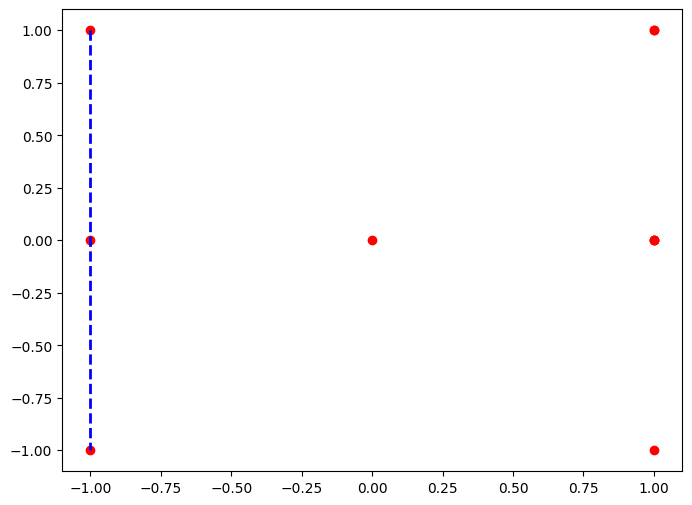

In [63]:


plt.figure(figsize=(8, 6))

X = generate_points(10)

plt.scatter(X[0], X[1], color='red', label='-1 (setosa)')

# Eine gute Entscheidungsgrenze (Decision Boundary):

b = random_boundary()
# Linie zwischen den Punkten (4.5, 2) und (6.5, 4.5).

# p1, p2 = decision_line_points(b, -1, 1)
p1 = (-1, f(b, -1))
p2 = (1, f(b, 1))

plt.plot(p1, p2, color='blue', linestyle='--', linewidth=2, label='Entscheidungsgrenze')

plt.show()

In [51]:
# Define function that calculates predictions
# input w : weight vector characterizing perceptron model : of shape (3,1)
# input X_ext : data matrix X, extended by a row of ones : of shape (3,m)
# return predictions : sign(w.transpose * x) : of shape (1,m)


def predict(w, X_ext):
  """
  Calculate perceptron predictions.
  w: weight vector with shape (3,1)
  X_ext: data matrix extended with ones, shape (3,m)
  returns: predictions of shape (1,m) with values in {-1, +1}
  """
  # compute linear scores (1,m)
  scores = np.matmul(w.T, X_ext)
  # convert to sign: -1 for negative, +1 for positive, treat 0 as +1
  predictions = np.sign(scores).astype(int)
  predictions[predictions == 0] = 1
  predictions = np.reshape(predictions, (1, X_ext.shape[1]))
  return predictions

In [61]:
m = 100

# Generate m random data points. X has shape (2,m)
X = generate_points(m)
# add a row of ones. X_ext has shape (3,m)
X_ext = np.vstack((np.ones((1,X.shape[1])), X))

# Generate random boundary. w has shape (3,1)
w = random_boundary()

# Generate labels. Y has shape (1,m)
Y = predict(w, X_ext)

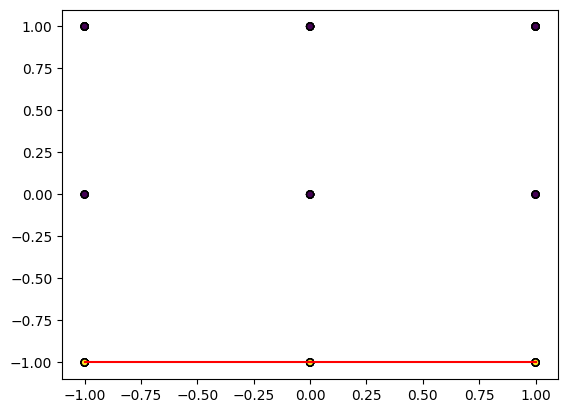

In [ ]:
# Visualize the data and the decision boundary
fig, ax = plt.subplots()
ax.scatter(X[0, :], X[1, :], marker='o', c=Y, s=25, edgecolor='k')

# the decision boundary characterized by vector w
xp = np.array((-1,1))
yp = -(w[1]/w[2]) * xp - (w[0]/w[2])

plt.axis([-1.1, 1.1, -1.1, 1.1])
plt.plot(xp, yp, "r-") # decision boundary
plt.show()

In [65]:
# Example of a point
index = 3
print("Point #" + str(index) + " is " + str(X[:,index]))
print("Class #" + str(index) + " is " + str(Y[0,index]))

Point #3 is [1 1]
Class #3 is 1


## **3 - Training**

In [67]:
# Define function for weight update

# input w : current weight vector with shape (3,1)
# input x : misclassified data point (should have shape (3,1))
# input y : label of data point x (scalar) -> which side of the boundary the point is

# return new_w : updated weight vector
def weight_update(w, x, y, learning_rate):
  """Perceptron weight update."""
  w = np.asarray(w)
  x = np.asarray(x)

  new_w = w + learning_rate * y * x
  new_w = new_w.reshape(3, 1)
  return new_w

  # new_w = np.reshape(new_w, (3,1))
  # return new_w

In [69]:
# Initialize weight vector w_ with zeros (3,1)
w_ = np.zeros((3,1))
learning_rate = 0.1
num_iterations = 10

# initialize array to save number of misclassified points in each iteration
num_misses = np.zeros(num_iterations)

# RNG for selecting a random misclassified point
rng = np.random.RandomState(42)

for i in range(num_iterations):
  # calculate predictions for all points (shape (1,m))
  preds = predict(w_, X_ext)

  # identify indices of misclassified points
  mismatches = np.where(preds.ravel() != Y.ravel())[0]

  # calculate and save number of misclassified points; break if none
  num_misses[i] = mismatches.size
  if num_misses[i] == 0:
    print(f"Converged after {i} iterations.")
    break

  # select random misclassified index
  idx = rng.choice(mismatches)

  # perform one weight update using datapoint at selected index
  x_i = X_ext[:, idx].reshape(3,1)
  y_i = int(Y[0, idx])
  w_ = weight_update(w_, x_i, y_i, learning_rate)

Converged after 3 iterations.


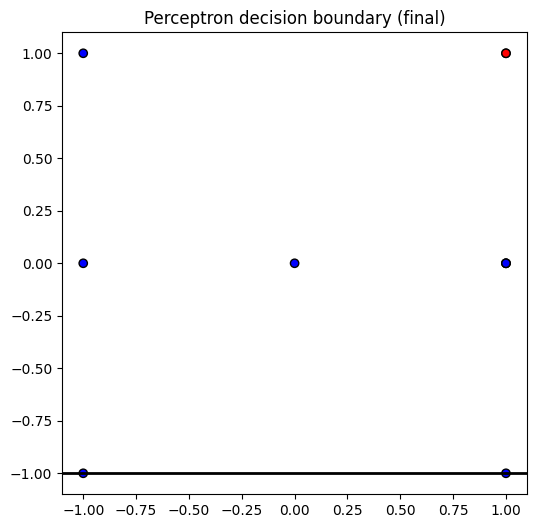

Misclassified points (final): 0


In [72]:
# Visualize learned boundary and data
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have final weights; if not, run a quick training
try:
    w_final = w_
except NameError:
    w_ = np.zeros((3,1))
    rng = np.random.RandomState(42)
    for _ in range(1000):
        preds = predict(w_, X_ext)
        mismatches = np.where(preds.ravel() != Y.ravel())[0]
        if mismatches.size == 0:
            break
        idx = rng.choice(mismatches)
        x_i = X_ext[:, idx].reshape(3,1)
        y_i = int(Y[0, idx])
        w_ = weight_update(w_, x_i, y_i, learning_rate)
    w_final = w_

# plot data colored by label
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[0, :], X[1, :], c=Y.ravel()[0:10], cmap='bwr', edgecolor='k')
xp = np.array([-1.1, 1.1])
yp = -(w_final[1]/w_final[2]) * xp - (w_final[0]/w_final[2])
ax.plot(xp, yp.flatten(), 'k-', linewidth=2)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_title('Perceptron decision boundary (final)')
plt.show()

# print number of misclassified points under final weights
preds_final = predict(w_final, X_ext)
print('Misclassified points (final):', np.sum(preds_final.ravel() != Y.ravel()))